In [1]:
import numpy as np
import pandas as pd
#import matplotlib.pyplot as Plt
import seaborn as sns


In [2]:
import matplotlib.pyplot as plt

# Overview

In [3]:
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
pd.Series(df['passengers'])

0       1
1       1
2       1
3       1
4       3
       ..
6428    1
6429    1
6430    1
6431    1
6432    1
Name: passengers, Length: 6433, dtype: int64

In [5]:
df.describe(include='all')

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000,6433,6389,6407,6388,6407,6388
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,194,203,4,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5451,4577,230,245,5268,5206
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794,NaN,NaN,NaN,NaN,NaN,NaN
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000,NaN,NaN,NaN,NaN,NaN,NaN
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000,NaN,NaN,NaN,NaN,NaN,NaN
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000,NaN,NaN,NaN,NaN,NaN,NaN
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000,NaN,NaN,NaN,NaN,NaN,NaN
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [7]:
print(df['pickup'].min())
print(df['pickup'].max())

2019-02-28 23:29:03
2019-03-31 23:43:45


In [8]:
df['color'].unique()

<StringArray>
['yellow', 'green']
Length: 2, dtype: str

## Insights
##### taxi rides records of March month.
##### All the quantitative fratures are not normally distributed, they are right skewed
##### taxi colors: yellow, green

# Distribution of categorical variables

In [9]:
df['color'].dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='str')

In [11]:
category = ['passengers', 'color', 'payment', 'pickup_borough','dropoff_borough']
cat = iter(category)
for i in range(6):
    try:
        col = next(cat)
        print(col)
    except StopIteration:
        pass
    

passengers
color
payment
pickup_borough
dropoff_borough


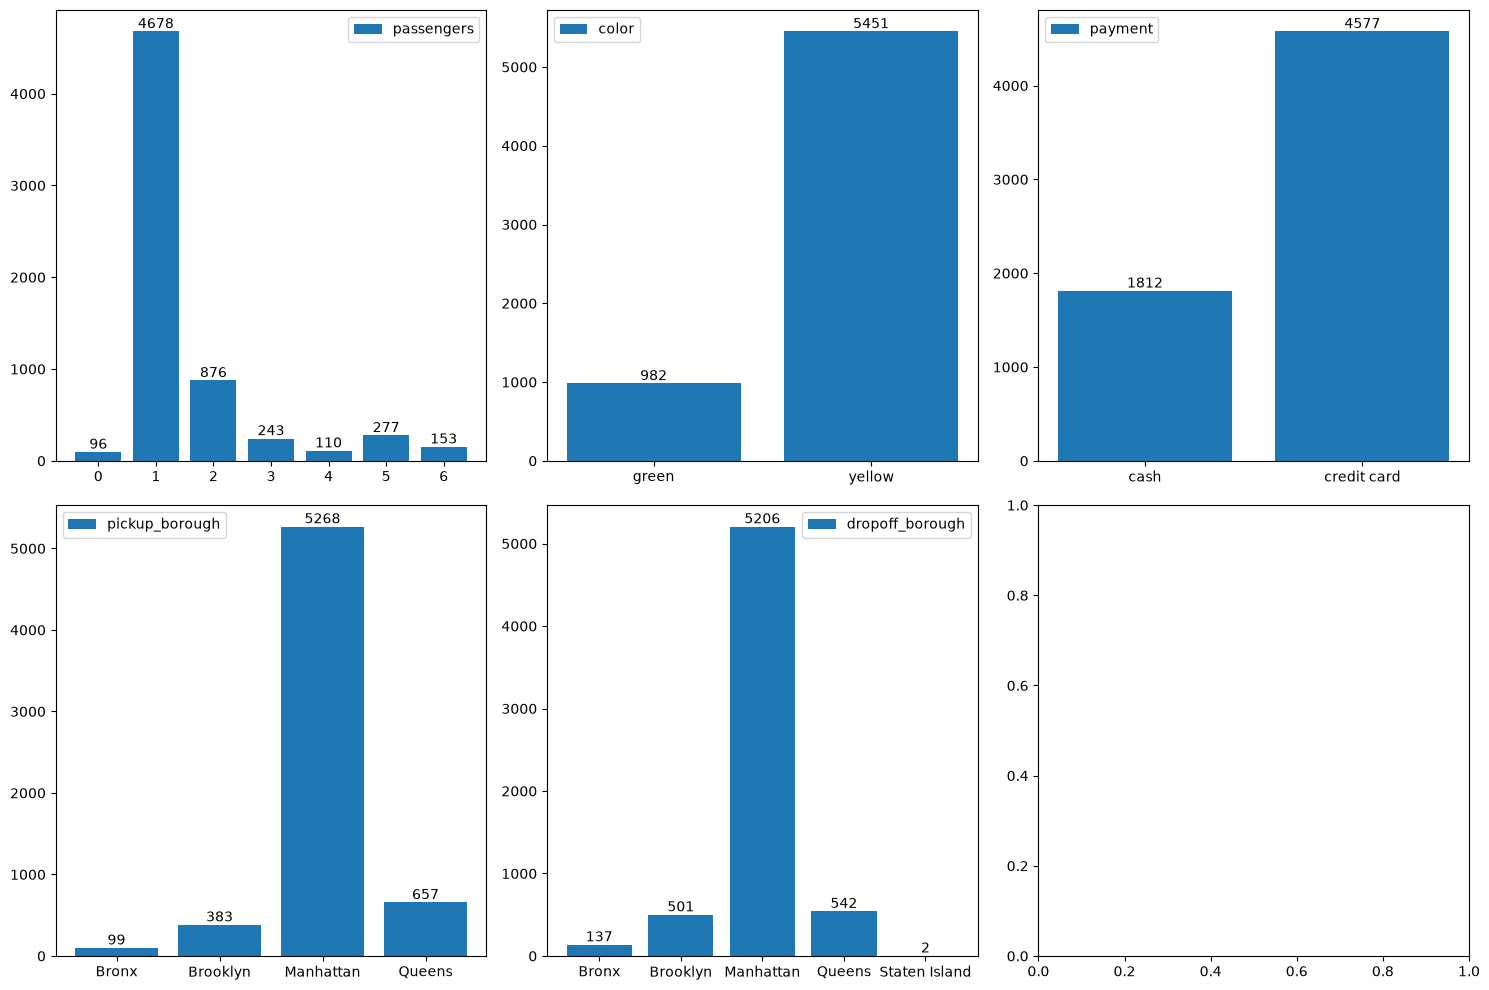

In [12]:
fig, ax = plt.subplots(2,3,figsize =(15,10))
category = ['passengers', 'color', 'payment', 'pickup_borough','dropoff_borough']
cat = iter(category)
def group(col):
     x = df.groupby(col)[col].count()
     return x
for i in range(2):
    for j in range(3):
        try:
            col = next(cat)
            data = group(col)
            bars = ax[i][j].bar(data.index, height = data, label=col)
            ax[i][j].bar_label(bars,label_type = "edge")
            ax[i][j].legend()
        except StopIteration:
            pass
plt.tight_layout()



## Insights
##### Most rides contains only one passanger
##### Yellow taxis were more
##### Most payments occurs through credit card
##### Most pickup and dropoff are from and to Manhattan & Queens

In [ ]:
# histogram of quantitative variables
# bar chart : x axis date, y axis total
# scatter plot of miniutes and total to check Correlation
# rouding of miniute column, then grouping by miniute and payment method, then plot bar chart, to undertand is interval has any connection with payment method or other categorical variable and quantitative variables

# Distrubution of Quantitative variables

In [13]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='str')

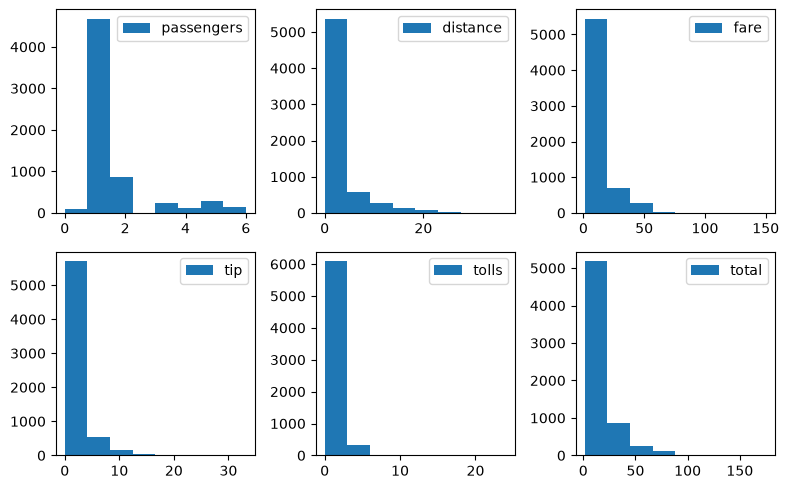

In [18]:
quantitative = ['passengers', 'distance', 'fare', 'tip', 'tolls','total',]
quant = iter(quantitative)
fig, ax = plt.subplots(2,3, figsize = (8,5))
for i in range(2):
    for j in range(3):
        col = next(quant)
        ax[i][j].hist(df[col], bins = 8, label = col)
        ax[i][j].legend()
plt.tight_layout()

## Insight
##### As we can it is right skewed data

# Heatmap of quantitative variables

In [19]:
np.array([])

array([], dtype=float64)

In [23]:
arra = np.array([])
arra

array([], dtype=float64)

In [21]:
x = [1,2,3,4]
np.array(x)

array([1, 2, 3, 4])

In [30]:
quantitative = ['passengers', 'distance', 'fare', 'tip', 'tolls','total',]
arra = []

In [31]:
for col in quantitative:
    arra.append(np.array(df[col]))
arra

[array([1, 1, 1, ..., 1, 1, 1], shape=(6433,)),
 array([1.6 , 0.79, 1.37, ..., 4.14, 1.12, 3.85], shape=(6433,)),
 array([ 7. ,  5. ,  7.5, ..., 16. ,  6. , 15. ], shape=(6433,)),
 array([2.15, 0.  , 2.36, ..., 0.  , 0.  , 3.36], shape=(6433,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(6433,)),
 array([12.95,  9.3 , 14.16, ..., 17.3 ,  6.8 , 20.16], shape=(6433,))]

In [34]:
corr = np.corrcoef(arra)

In [36]:
corr

array([[ 1.        ,  0.0094111 ,  0.00763706,  0.0210993 , -0.00290305,
         0.01570785],
       [ 0.0094111 ,  1.        ,  0.9201077 ,  0.45258866,  0.63526738,
         0.90467642],
       [ 0.00763706,  0.9201077 ,  1.        ,  0.4886124 ,  0.60930692,
         0.97435764],
       [ 0.0210993 ,  0.45258866,  0.4886124 ,  1.        ,  0.4136188 ,
         0.64618579],
       [-0.00290305,  0.63526738,  0.60930692,  0.4136188 ,  1.        ,
         0.68314222],
       [ 0.01570785,  0.90467642,  0.97435764,  0.64618579,  0.68314222,
         1.        ]])

<Axes: >

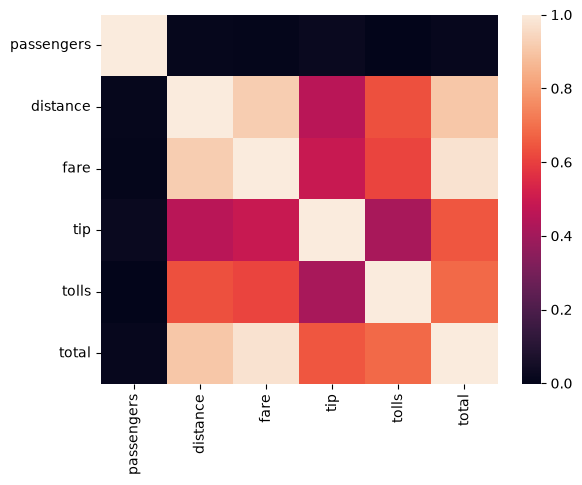

In [37]:
sns.heatmap(corr, xticklabels=quantitative, yticklabels=quantitative)

## Insights
##### tolls and toatal are correlated
##### Distance vs Fare vs tolls are highly correlated
##### Distance vd tip are less correlated
##### fare vs tip vs toll are less correlated